In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("diabetes.csv")

In [4]:
print(df.head())
print(df.info())
print(df.describe())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

In [5]:
print(df.isnull().sum())
print(df.duplicated().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
0


In [6]:
X = df[
    [
        "Glucose",
        "BMI",
        "Age",
        "Insulin",
        "Pregnancies",
        "DiabetesPedigreeFunction"
    ]
]

y = df["Outcome"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# Predict whether a patient has diabetes based on medical features such as glucose level, BMI, age, insulin level, and number of pregnancies.

In [10]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression
Accuracy : 0.7597402597402597
[[81 18]
 [19 36]]
              precision    recall  f1-score   support

           0       0.81      0.82      0.81        99
           1       0.67      0.65      0.66        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



In [11]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy : 0.7467532467532467
[[76 23]
 [16 39]]
              precision    recall  f1-score   support

           0       0.83      0.77      0.80        99
           1       0.63      0.71      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



In [12]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print()

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_knn))
print()

print("Classification Report")
print(classification_report(y_test, y_pred_knn))

Accuracy : 0.6948051948051948

Confusion Matrix
[[75 24]
 [23 32]]

Classification Report
              precision    recall  f1-score   support

           0       0.77      0.76      0.76        99
           1       0.57      0.58      0.58        55

    accuracy                           0.69       154
   macro avg       0.67      0.67      0.67       154
weighted avg       0.70      0.69      0.70       154



                 Model  Accuracy
0  Logistic Regression  0.759740
1        Random Forest  0.746753
2                  KNN  0.694805


<Axes: >

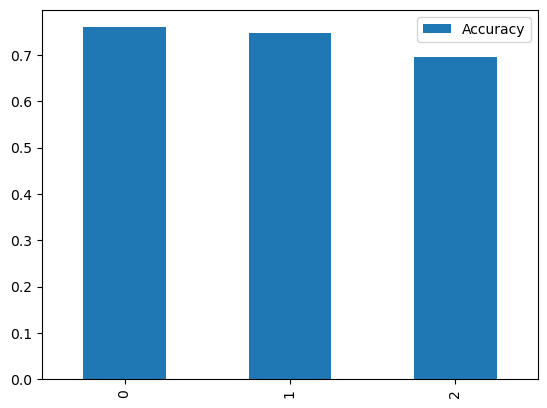

In [17]:
comparison = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","KNN"],
    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test, y_pred_knn)
        
    ]
})

print(comparison)
comparison.plot(kind = "bar")

In [14]:
import pickle

with open("logistic_regression_model.pkl", "wb") as file:
    pickle.dump(lr, file)

print("Model saved successfully!")

Model saved successfully!


In [16]:
with open("logistic_regression_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

new_patient = pd.DataFrame({
    "Glucose": [120],
    "BMI": [28.5],
    "Age": [35],
    "Insulin": [130],
    "Pregnancies": [2],
    "DiabetesPedigreeFunction": [0.45]
})
print(loaded_model.predict(new_patient))


Model loaded successfully!
[1]


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
